In [2]:
# Use this in Colab session
#%cd /content
#!rm -rf rainfall_kf
#
#!git clone https://github.com/Felix-Schwer/rainfall_kf.git
#%cd rainfall_kf

# Use this on local machine
%cd C:/Users/fschwer/Documents/CEE 261D Data Assimilation/Final Project/rainfall_kf

!pip install -e .

C:\Users\fschwer\Documents\CEE 261D Data Assimilation\Final Project\rainfall_kf
Obtaining file:///C:/Users/fschwer/Documents/CEE%20261D%20Data%20Assimilation/Final%20Project/rainfall_kf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for rainfall_kf (pyproject.toml): started
  Building editable for rainfall_kf (pyproject.toml): finished with status 'done'
  Created wheel for rainfall_kf: filename=rainfall_kf-0.1.0-0.editable-py3-none-any.whl size=2787 sha256=010c295969ca20a2ce8810d1b122dad555ef24e92f80a1d2df77f0a57e00f71b
  St

In [75]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# have to cd on local machine
%cd C:/Users/fschwer/Documents/CEE 261D Data Assimilation/Final Project/rainfall_kf/notebooks

prism_ds = xr.open_dataset('../data/prism_basin_means.nc')
gpm_ds = xr.open_dataset('../data/gpm_basin_means.nc')
et_ds = xr.open_dataset('../data/et_basin_means.nc')
temp_ds = xr.open_dataset('../data/temp_basin_means.nc')

from rainfall_kf.models.hbvedu import processed_inputs_fromds
et_ds, (monthly_et, monthly_temp) = processed_inputs_fromds(et_ds, temp_ds, starttime='2000-01-01', endtime='2020-12-31')


C:\Users\fschwer\Documents\CEE 261D Data Assimilation\Final Project\rainfall_kf\notebooks


In [76]:
stations_in_basin = {
    "18040001": ["11273400"], # Middle San Joaquin-Lower Chowchilla
    "18040002": ["11274550"], # Lower San Joaquin River
    "18040003": ["11303500"], # San Joaquin Delta
    "18040006": [], # Upper San Joaquin
    "18040007": [], # Fresno River
    "18040008": ["11272500"],# Upper Merced
    "18040009": ["11290000"], # Upper Tuolumne
    "18040010": ["11303000"], # Upper Stanislaus
    "18040011": [], # Upper Calaveras
    "18040012": ["11325500"], # Upper Mokelumne
    "18040013": [], # Upper Cosumnes
    "18040014": ["11255575"] # Panoche-San Luis Reservoir
}

stream_ds = xr.open_dataset('../data/streamflow.nc')

In [77]:
from rainfall_kf.models.hbv2 import SJV_Sierra_UBParameters, SJV_Sierra_LBParameters, SJV_Valley_UBParameters, SJV_Valley_LBParameters
Params = 0.2 * SJV_Valley_UBParameters + (1 - 0.2) * SJV_Valley_LBParameters

In [78]:
basin_id = "18040009"
station_id = stations_in_basin[basin_id][0]
start_time = stream_ds.sel(site=station_id).continuous_start.values
end_time = stream_ds.sel(site=station_id).continuous_end.values

In [79]:
inputs = np.array([
    temp_ds.tmean.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    gpm_ds.precipitation.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_temp.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_et.sel(basin=basin_id, time=slice(start_time, end_time)).values
])

times = stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).time.values
observations_imperial = np.array([stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).values])
cfs_to_m3s = 0.0283168
sqmi_to_km2 = 2.58999
basin_area_km2 = stream_ds.sel(site=station_id).drainage_area.values * sqmi_to_km2
observations = observations_imperial * cfs_to_m3s / basin_area_km2 # m3/s/km2
observations = observations * 86400 / 1000000 * 1000 # m/day

In [80]:
def MBE(a, b):
    return np.mean(a - b)
def PBIAS(a, b):
    return np.sum(a - b) / np.sum(b)
def RMSE(a, b):
    return np.sqrt(np.mean((a - b)**2))
def PearsonR(a, b):
    return np.corrcoef(a, b)[0, 1]
def NSE(a, b):
    return 1 - np.sum((a - b)**2) / np.sum((b - np.mean(b))**2)
def KGE(a, b):
    a_bar = np.mean(a)
    b_bar = np.mean(b)
    return 1 - np.sqrt(np.sum((a - b)**2) / np.sum((a - a_bar)**2 + (b - b_bar)**2))

In [81]:
from rainfall_kf.enkf import EnsembleKalmanFilter
from rainfall_kf.models.hbvedu import HBVTransition, HBVObservation
from rainfall_kf.models.hbv2 import RainfallCorrTransition, RainfallCorrObservation
from itertools import product

RUNS = {'correction': ['additive', 'multiplicative', 'logmul'], 'method': ['random_walk','autoregressive'], 'storm_threshold': [0, 5]}
CONFIGS = [(correction, method, storm_threshold) for correction, method, storm_threshold in product(RUNS["correction"], RUNS["method"], RUNS["storm_threshold"])]
SIGB = {'additive': 5, 'multiplicative': 0.5, 'logmul': 0.02}

metric_names = ['RMSE', 'PBIAS', 'r', 'NSE', 'KGE']
metrics = xr.DataArray(np.nan, dims=['correction', 'method', 'storm_threshold', 'metric'],
    coords={'correction': RUNS['correction'], 'method': RUNS['method'], 'storm_threshold': RUNS['storm_threshold'], 'metric': metric_names})

gpm = gpm_ds.precipitation.sel(basin=basin_id, time=slice(start_time + pd.Timedelta(days=366), end_time))
prism = prism_ds.precipitation.sel(basin=basin_id, time=slice(start_time + pd.Timedelta(days=366), end_time))

for correction, method, storm_threshold in CONFIGS:
    print(f"Running with correction={correction}, method={method}, storm_threshold={storm_threshold}")
    if (correction == 'logmul' or correction == 'additive') and method == 'random_walk':
        print("Skipping logmul with random_walk due to expected instability.")
        continue
    
    N_STATES = 6
    N_OBS = 1
    N_ENS = 100

    Qassumed = np.diag([2, 2, 0.5, 0.5, 1e-40, SIGB[correction]])**2
    Rassumed = np.diag([0.5])**2

    x0 = np.array([[0., 100., 10., 10., 10., 0.]]).T # initial state guess

    initial_ensemble = x0 + np.linalg.cholesky(Qassumed).T @ np.random.randn(N_STATES, N_ENS)

    THRESH = None if storm_threshold == 0 else storm_threshold
    TransitionEquation = lambda states, inputs: RainfallCorrTransition(states, inputs, Params, correction=correction, method=method, storm_threshold=THRESH, phi=0.8)

    enkf = EnsembleKalmanFilter(
        TransitionEquation=TransitionEquation,
        ObservationEquation=lambda states: HBVObservation(states, Params),
        Q=Qassumed,
        R=Rassumed,
        addGaussInputSig=np.array([0.2, 0., 0., 0.]),
        mulLognormInputSig=np.array([0., 0.2, 0., 0.]),
        gain_method='pinv', #pinv or analytic
    )

    try:
        result = enkf.run(initial_ensemble=initial_ensemble, times=times, inputs=inputs, observations=observations)

        b = xr.DataArray(result.ensembles[:, 5, :].mean(axis=1), coords=[times], dims=['time']).sel(time=slice(start_time + pd.Timedelta(days=366), end_time))
        if correction == 'additive':
            corrected = gpm + b.where(gpm >= storm_threshold, 0)
        elif correction == 'multiplicative':
            corrected = gpm * (1 + b.where(gpm >= storm_threshold, 0))
        elif correction == 'logmul':
            corrected = gpm * np.exp(b.where(gpm >= storm_threshold, 0))

        rmse = RMSE(corrected.where(prism > 10), prism.where(prism > 10))
        pbias = PBIAS(corrected.where(prism > 10), prism.where(prism > 10))
        r = PearsonR(corrected.where(prism > 10).dropna(dim='time'), prism.where(prism > 10).dropna(dim='time'))
        nse = NSE(corrected, prism)
        kge = KGE(corrected, prism)

        metrics.loc[correction, method, storm_threshold, :] = [rmse, pbias, r, nse, kge]    
    except Exception as e:
        print(f"Error occurred for configuration {correction}, {method}, {storm_threshold}: {e}")
        continue


Running with correction=additive, method=random_walk, storm_threshold=0
Skipping logmul with random_walk due to expected instability.
Running with correction=additive, method=random_walk, storm_threshold=5
Skipping logmul with random_walk due to expected instability.
Running with correction=additive, method=autoregressive, storm_threshold=0
Running with correction=additive, method=autoregressive, storm_threshold=5
Running with correction=multiplicative, method=random_walk, storm_threshold=0
Running with correction=multiplicative, method=random_walk, storm_threshold=5
Running with correction=multiplicative, method=autoregressive, storm_threshold=0
Running with correction=multiplicative, method=autoregressive, storm_threshold=5
Running with correction=logmul, method=random_walk, storm_threshold=0
Skipping logmul with random_walk due to expected instability.
Running with correction=logmul, method=random_walk, storm_threshold=5
Skipping logmul with random_walk due to expected instability.


In [82]:
badd_mean = (prism.where(prism > 10).dropna(dim='time')-gpm.where(prism > 10).dropna(dim='time')).mean().values.item()
additive_baseline = gpm + np.where(gpm > 5, badd_mean, 0)

bmul_median = (prism.where(prism > 10).dropna(dim='time')/gpm.where(prism > 10).dropna(dim='time')-1).median().values.item()
multiplicative_baseline = gpm * (1 + np.where(gpm > 5, bmul_median, 0))

blogmul_median = np.median(np.log1p(prism.where(prism > 10).dropna(dim='time')/gpm.where(prism > 10).dropna(dim='time')))
logmul_baseline = gpm * np.exp(np.where(gpm > 5, blogmul_median, 0))

baseline_results = []
baseline_series = {'additive': additive_baseline, 'multiplicative': multiplicative_baseline, 'logmul': logmul_baseline}

for name, series in baseline_series.items():
    baseline_results.append({'correction': name,'method': 'baseline','storm_threshold': 5,'metric': 'RMSE','value': RMSE(series.where(prism > 10).dropna(dim='time').values, prism.where(prism > 10).dropna(dim='time').values)})
    baseline_results.append({'correction': name,'method': 'baseline','storm_threshold': 5,'metric': 'PBIAS','value': PBIAS(series.where(prism > 10).dropna(dim='time').values, prism.where(prism > 10).dropna(dim='time').values)})
    baseline_results.append({'correction': name,'method': 'baseline','storm_threshold': 5,'metric': 'r','value': PearsonR(series.where(prism > 10).dropna(dim='time').values, prism.where(prism > 10).dropna(dim='time').values)})
    baseline_results.append({'correction': name,'method': 'baseline','storm_threshold': 5,'metric': 'NSE','value': NSE(series.dropna(dim='time').values, prism.dropna(dim='time').values)})
    baseline_results.append({'correction': name,'method': 'baseline','storm_threshold': 5,'metric': 'KGE','value': KGE(series.dropna(dim='time').values, prism.dropna(dim='time').values)})

baseline_results.append({'correction': 'uncorrected','method': 'baseline','storm_threshold': 0,'metric': 'RMSE','value': RMSE(gpm.where(prism > 10).dropna(dim='time').values, prism.where(prism > 10).dropna(dim='time').values)})
baseline_results.append({'correction': 'uncorrected','method': 'baseline','storm_threshold': 0,'metric': 'PBIAS','value': PBIAS(gpm.where(prism > 10).dropna(dim='time').values, prism.where(prism > 10).dropna(dim='time').values)})
baseline_results.append({'correction': 'uncorrected','method': 'baseline','storm_threshold': 0,'metric': 'r','value': PearsonR(gpm.where(prism > 10).dropna(dim='time').values, prism.where(prism > 10).dropna(dim='time').values)})
baseline_results.append({'correction': 'uncorrected','method': 'baseline','storm_threshold': 0,'metric': 'NSE','value': NSE(gpm.dropna(dim='time').values, prism.dropna(dim='time').values)})
baseline_results.append({'correction': 'uncorrected','method': 'baseline','storm_threshold': 0,'metric': 'KGE','value': KGE(gpm.dropna(dim='time').values, prism.dropna(dim='time').values)})

baseline_df = pd.DataFrame(baseline_results)

In [71]:
combined_df

,correction,method,storm_threshold,metric,value,config
0,additive,random_walk,0,RMSE,NaN,random_walk_thr=0
1,additive,random_walk,0,PBIAS,NaN,random_walk_thr=0
2,additive,random_walk,0,r,NaN,random_walk_thr=0
3,additive,random_walk,0,NSE,NaN,random_walk_thr=0
4,additive,random_walk,0,KGE,NaN,random_walk_thr=0
...,...,...,...,...,...,...
70,logmul,baseline,5,RMSE,77.060680,baseline_thr=5
71,logmul,baseline,5,PBIAS,1.094766,baseline_thr=5
72,logmul,baseline,5,r,0.415845,baseline_thr=5
73,logmul,baseline,5,NSE,-8.932459,baseline_thr=5


In [88]:
combined_df['config'].str.contains('baseline')

0     False
1     False
2     False
3     False
4     False
      ...  
75     True
76     True
77     True
78     True
79     True
Name: config, Length: 80, dtype: bool

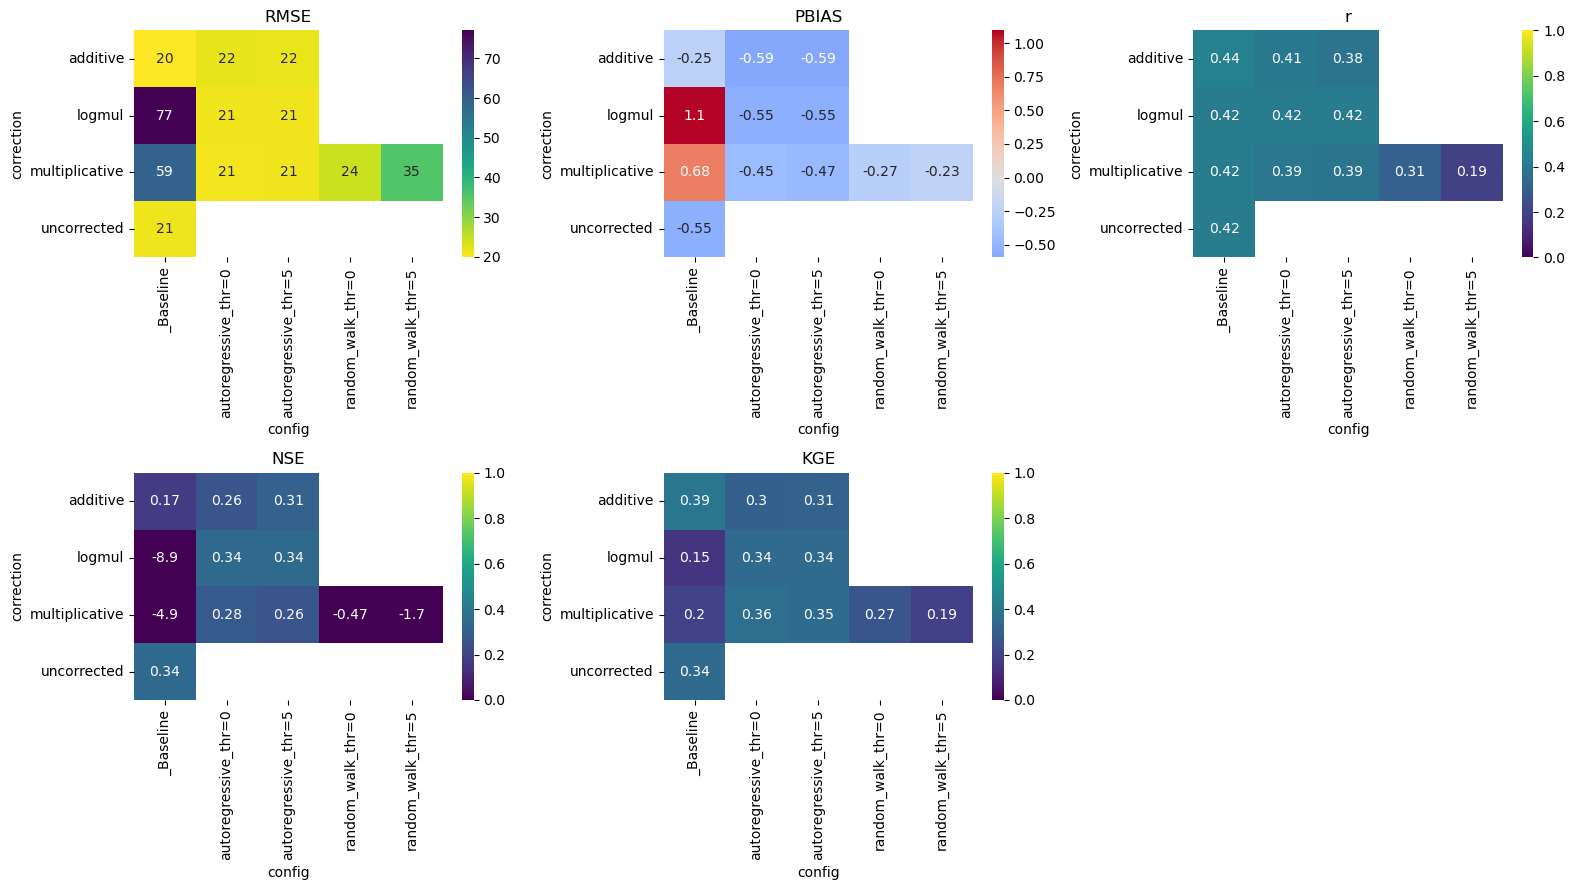

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics_df = (metrics.to_dataframe(name='value').reset_index())
# Combine with baselines
combined_df = pd.concat([metrics_df, baseline_df],ignore_index=True)

# Create plotting config labels
combined_df['config'] = (combined_df['method'].astype(str)+ '_thr='+ combined_df['storm_threshold'].astype(str))
combined_df.loc[combined_df['config'].str.contains('baseline'), 'config'] = '_Baseline'

metric_names = ['RMSE', 'PBIAS', 'r', 'NSE', 'KGE']

cmaps = {'RMSE': 'viridis_r','PBIAS': 'coolwarm','r': 'viridis','NSE': 'viridis','KGE': 'viridis'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, metric in enumerate(metric_names):

    df_metric = combined_df[
        combined_df['metric'] == metric
    ]

    pivot = df_metric.pivot(
        index='correction',
        columns='config',
        values='value'
    )

    kwargs = {}

    if metric == 'PBIAS':
        kwargs['center'] = 0

    if metric in ['r', 'NSE', 'KGE']:
        kwargs['vmin'] = 0
        kwargs['vmax'] = 1

    sns.heatmap(
        pivot,
        annot=True,
        cmap=cmaps[metric],
        ax=axes[i],
        **kwargs
    )

    axes[i].set_title(metric)

# Remove unused panel
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()